# LIWC Heatmaps + Support Bar Charts

### Heatmap 1 — Posts
- **Rows**: 3 stigma categories
  - Cat A: Internalized / Experienced / Anticipated
  - Cat B: Structural
  - Cat C: No Stigma
- **Columns**: Analytic, Clout, Authentic, Tone
- **Value**: mean LIWC across posts in that category (each post counted ONCE, deduped on post_id)

### Heatmap 2 — Comments
- **THREE sub-heatmaps side by side** — one per stigma category
- Each sub-heatmap: rows = 5 support types, cols = Analytic/Clout/Authentic/Tone
- **Value**: mean LIWC of comments that have that support type AND belong to that stigma category
- Each comment is a unique observation — no deduplication

### Bar Charts — 3 panels in one figure
- % of posts in each stigma category that include each support type

> No normalization anywhere — all raw LIWC values

In [102]:
%pip install matplotlib
%pip install seaborns

Note: you may need to restart the kernel to use updated packages.
ERROR: Could not find a version that satisfies the requirement seaborns (from versions: none)
ERROR: No matching distribution found for seaborns
Note: you may need to restart the kernel to use updated packages.


In [103]:
# ══════════════════════════════════════════════════════════════════════
# CELL 1 — IMPORTS & LOAD DATA
# ══════════════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Adjust paths if your CSVs are in a different folder
stigma_posts    = pd.read_csv("/Users/karanbindal/Desktop/Research/LIWC-22 posts Results - final stigma and support with ___ - LIWC Analysis.csv",    engine="python")
stigma_comments = pd.read_csv("/Users/karanbindal/Desktop/Research/LIWC-22 comment Results - final stigma and support with ___ - LIWC Analysis.csv",  engine="python")
ns_posts        = pd.read_csv("/Users/karanbindal/Desktop/Research/LIWC-22 post Results - no_stigma_support_predictions____ - LIWC Analysis.csv",     engine="python")
ns_comments     = pd.read_csv("/Users/karanbindal/Desktop/Research/LIWC-22 comment Results - no_stigma_support_predictions____ - LIWC Analysis.csv", engine="python")

print(f"stigma_posts    : {stigma_posts.shape}")
print(f"stigma_comments : {stigma_comments.shape}")
print(f"ns_posts        : {ns_posts.shape}")
print(f"ns_comments     : {ns_comments.shape}")

# The 4 LIWC columns — raw values, no normalization
LIWC4 = ["Analytic", "Clout", "Authentic", "Tone"]

# 5 support types present in the data
SUPPORT_TYPES = [
    "Emotional Support",
    "Esteem Support",
    "Group Interaction",
    "Information Support",
    "Tangible Assistance",
]

stigma_posts    : (4631, 147)
stigma_comments : (4626, 147)
ns_posts        : (1175, 133)
ns_comments     : (1175, 133)


In [104]:
# ══════════════════════════════════════════════════════════════════════
# CELL 2 — CATEGORY DEFINITIONS & EXPLODE HELPER
# ══════════════════════════════════════════════════════════════════════
#
# l3 labels in the data: Internalized, Experienced, Anticipated, Structural
#
# Category A = Internalized / Experienced / Anticipated
# Category B = Structural
# Category C = No Stigma  (separate files, no l3_labels column)
#
# A post tagged "Experienced, Structural" is counted in BOTH Cat A AND Cat B.

CAT_A_LABELS = {"Internalized", "Experienced", "Anticipated"}
CAT_B_LABELS = {"Structural"}

CAT_A = "Internalized /\nExperienced /\nAnticipated"
CAT_B = "Structural"
CAT_C = "No Stigma"
CAT_ORDER = [CAT_A, CAT_B, CAT_C]


def explode_col(df, col):
    """Split comma-separated values in col — one row per value."""
    d = df.copy()
    d[col] = d[col].fillna("").astype(str).str.split(",")
    d = d.explode(col)
    d[col] = d[col].str.strip()
    return d[d[col] != ""].copy()


def assign_category(label):
    if label in CAT_A_LABELS:
        return CAT_A
    if label in CAT_B_LABELS:
        return CAT_B
    return None


# Explode l3_labels and assign category for stigma posts & comments
sp_exp = explode_col(stigma_posts, "l3_labels")
sp_exp["category"] = sp_exp["l3_labels"].map(assign_category)
sp_exp = sp_exp[sp_exp["category"].notna()].copy()

sc_exp = explode_col(stigma_comments, "l3_labels")
sc_exp["category"] = sc_exp["l3_labels"].map(assign_category)
sc_exp = sc_exp[sc_exp["category"].notna()].copy()

print("Unique l3 labels:", sorted(sp_exp["l3_labels"].unique()))
print("\nPost rows per category after explode:")
print(sp_exp["category"].value_counts().to_string())
print("\nComment rows per category after explode:")
print(sc_exp["category"].value_counts().to_string())

Unique l3 labels: ['Anticipated', 'Experienced', 'Internalized', 'Structural']

Post rows per category after explode:
category
Internalized /\nExperienced /\nAnticipated    8237
Structural                                     608

Comment rows per category after explode:
category
Internalized /\nExperienced /\nAnticipated    8227
Structural                                     607


In [105]:
# ══════════════════════════════════════════════════════════════════════
# CELL 3 — HEATMAP 1 DATA
# ══════════════════════════════════════════════════════════════════════

# Dedup on (post_id, l3_labels) — collapses comment repetitions
# but keeps multiple rows if post has multiple stigma labels
# Post with 5 comments + 1 label  → 1 row
# Post with 5 comments + 2 labels → 2 rows
sp_dedup_correct = sp_exp.drop_duplicates(subset=["post_id", "l3_labels"])
cat_avg = sp_dedup_correct.groupby("category")[LIWC4].mean()

# No stigma: just dedup on post_id (no stigma labels to worry about)
ns_posts_dedup = ns_posts.drop_duplicates(subset=["post_id"])
ns_avg = ns_posts_dedup[LIWC4].mean().to_frame().T
ns_avg.index = [CAT_C]

heatmap1_df = pd.concat([cat_avg, ns_avg]).reindex(CAT_ORDER)

print("HEATMAP 1 — raw mean LIWC per category (posts):")
print(heatmap1_df.round(3))
print()
print("Post rows per category (each post counted once per stigma label):")
print(sp_dedup_correct.groupby("category").size().to_string())
print(f"No Stigma unique posts: {ns_posts_dedup['post_id'].nunique()}")

HEATMAP 1 — raw mean LIWC per category (posts):
                                            Analytic   Clout  Authentic  \
Internalized /\nExperienced /\nAnticipated    10.004  11.170     84.202   
Structural                                    16.491  18.002     76.486   
No Stigma                                     14.520  17.817     75.779   

                                              Tone  
Internalized /\nExperienced /\nAnticipated  11.274  
Structural                                  11.597  
No Stigma                                   18.746  

Post rows per category (each post counted once per stigma label):
category
Internalized /\nExperienced /\nAnticipated    4407
Structural                                     325
No Stigma unique posts: 551


Saved: heatmap1_posts_liwc.png


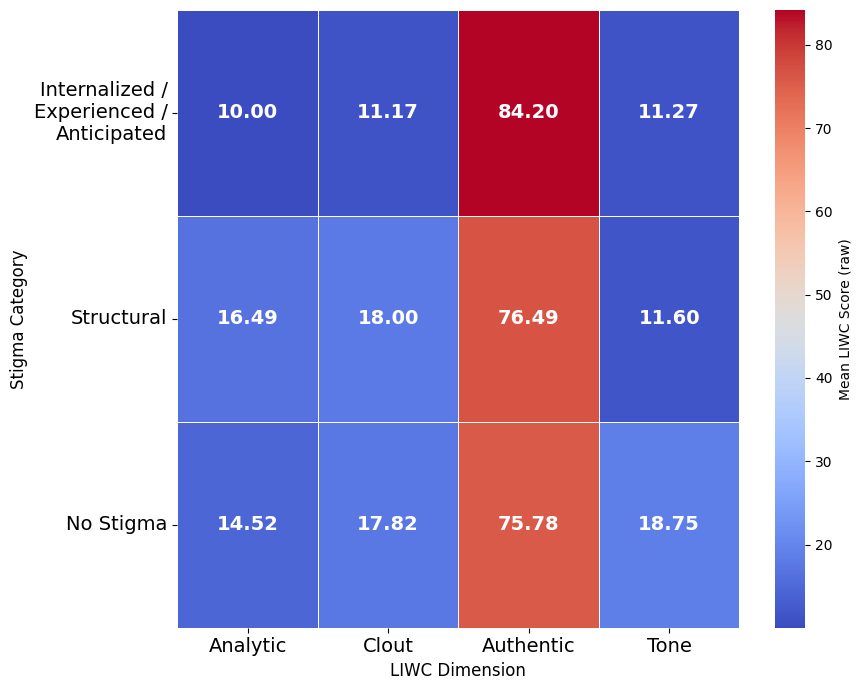

In [106]:
# ══════════════════════════════════════════════════════════════════════
# CELL 4 — DRAW HEATMAP 1
# ══════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(9,7))

sns.heatmap(
    heatmap1_df,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    linecolor="white",
    annot_kws={"size": 14, "weight": "bold"},
    cbar_kws={"label": "Mean LIWC Score (raw)"},
    ax=ax
)


ax.set_xlabel("LIWC Dimension", fontsize=12)
ax.set_ylabel("Stigma Category", fontsize=12)
ax.tick_params(axis="x", labelsize=14, rotation = 0)
ax.tick_params(axis="y", labelsize=14, rotation=0)

plt.tight_layout()
plt.savefig("heatmap1_posts_liwc.png", dpi=180, bbox_inches="tight", pad_inches=0)
print("Saved: heatmap1_posts_liwc.png")
plt.show()
plt.close()

In [107]:
# ══════════════════════════════════════════════════════════════════════
# CELL 5 — HEATMAP 2 DATA: COMMENTS LIWC BY (STIGMA CATEGORY x SUPPORT TYPE)
#
# This answers: "For comments in [stigma category] posts that received
# [support type] — what is the average Analytic / Clout / Authentic / Tone?"
#
# The result is THREE separate DataFrames (one per stigma category),
# each shaped: rows = 5 support types, cols = Analytic/Clout/Authentic/Tone.
#
# Mechanics:
#   - Comments file LIWC = the comment's own text (different per comment row).
#   - Each comment row is a unique observation — no deduplication.
#   - Explode l3_labels: a comment on a "Experienced, Structural" post
#     appears in both Cat A and Cat B.
#   - Explode support_tags: a comment tagged "Emotional Support, Esteem Support"
#     is counted in both those support rows.
#   - Group by (category, support_tag) → mean of LIWC4.
#
# For No Stigma comments: no l3_labels column, all go into Cat C.
#   - Explode support_labels column.
#   - Group by support_label → mean of LIWC4.
# ══════════════════════════════════════════════════════════════════════

# Stigma comments: explode support_tags
# (sc_exp already has l3_labels exploded and category assigned from Cell 2)
sc_sup = explode_col(sc_exp, "support_tags")
sc_sup = sc_sup[sc_sup["support_tags"].isin(SUPPORT_TYPES)]

# Mean LIWC per (stigma category, support type)
stigma_comment_avg = (
    sc_sup
    .groupby(["category", "support_tags"])[LIWC4]
    .mean()
)

# No-stigma comments: explode support_labels
nsc_sup = explode_col(ns_comments, "support_labels")
nsc_sup = nsc_sup[nsc_sup["support_labels"].isin(SUPPORT_TYPES)]
ns_comment_avg = (
    nsc_sup
    .groupby("support_labels")[LIWC4]
    .mean()
)
ns_comment_avg.index.name = "support_tags"

# Build one DataFrame per category: rows=SUPPORT_TYPES, cols=LIWC4
heatmap2 = {}

for cat in [CAT_A, CAT_B]:
    if cat in stigma_comment_avg.index.get_level_values("category"):
        df = stigma_comment_avg.loc[cat].reindex(SUPPORT_TYPES)
    else:
        df = pd.DataFrame(np.nan, index=SUPPORT_TYPES, columns=LIWC4)
    heatmap2[cat] = df

heatmap2[CAT_C] = ns_comment_avg.reindex(SUPPORT_TYPES)

for cat in CAT_ORDER:
    print(f"\nHEATMAP 2 — {cat.replace(chr(10),' ')}:")
    print(heatmap2[cat].round(3))


HEATMAP 2 — Internalized / Experienced / Anticipated:
                     Analytic   Clout  Authentic    Tone
support_tags                                            
Emotional Support       9.717  72.006     40.436  31.936
Esteem Support         11.444  76.263     35.525  28.476
Group Interaction      11.899  52.518     58.192  32.594
Information Support    16.231  74.388     35.410  27.662
Tangible Assistance    16.895  69.456     48.053  39.320

HEATMAP 2 — Structural:
                     Analytic   Clout  Authentic    Tone
support_tags                                            
Emotional Support      12.975  70.645     37.024  36.694
Esteem Support         12.986  77.502     34.046  37.698
Group Interaction      13.980  52.684     51.521  41.668
Information Support    19.684  73.029     33.595  33.159
Tangible Assistance    21.554  68.035     45.374  45.050

HEATMAP 2 — No Stigma:
                     Analytic   Clout  Authentic    Tone
support_tags                             

Saved: heatmap2_comments_liwc_catA.png


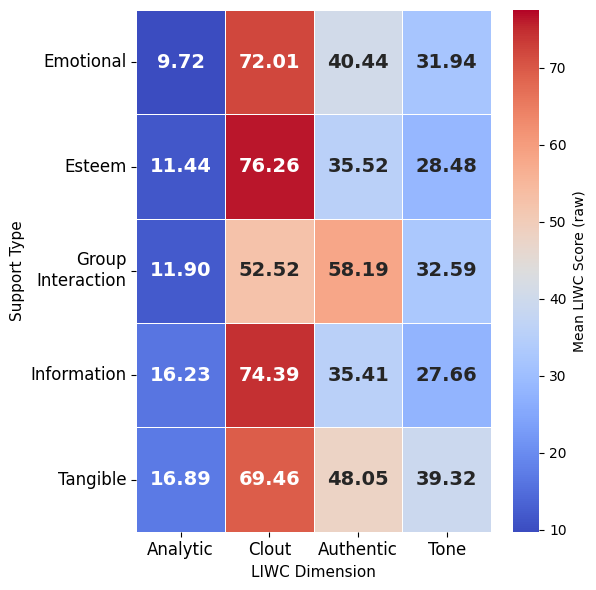

Saved: heatmap2_comments_liwc_catB.png


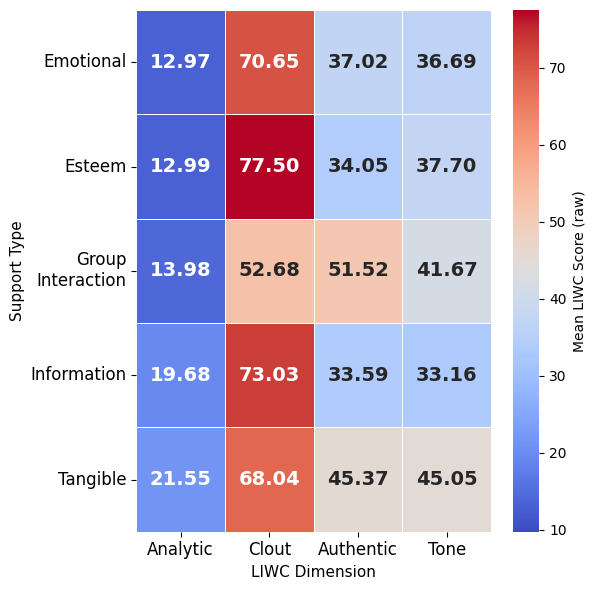

Saved: heatmap2_comments_liwc_catC.png


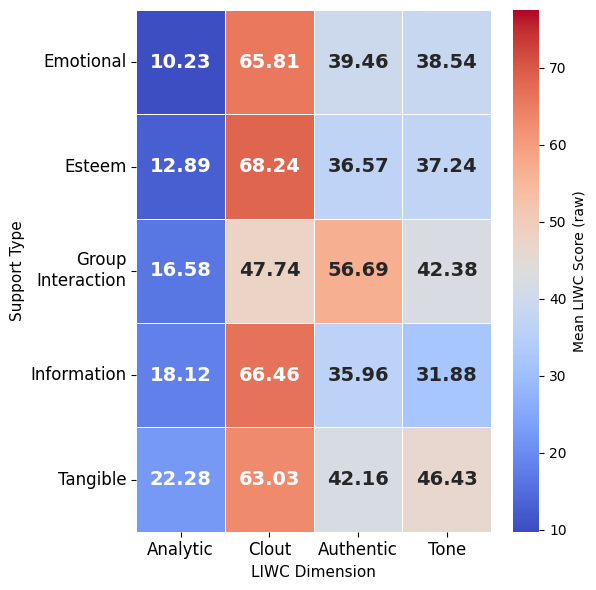

In [108]:
# ══════════════════════════════════════════════════════════════════════
# CELL 6 — DRAW HEATMAP 2 AS 3 SEPARATE IMAGES
#
# One image per stigma category.
# Rows = support type, Cols = LIWC4, Value = raw mean.
# Shared colour scale across all three images.
# ══════════════════════════════════════════════════════════════════════

SHORT_SUPPORT = {
    "Emotional Support"  : "Emotional",
    "Esteem Support"     : "Esteem",
    "Group Interaction"  : "Group\nInteraction",
    "Information Support": "Information",
    "Tangible Assistance": "Tangible",
}
short_index = [SHORT_SUPPORT[s] for s in SUPPORT_TYPES]

# Shared vmin/vmax for consistent colour scale across all saved images
all_vals = pd.concat(heatmap2.values()).values.flatten()
vmin = np.nanmin(all_vals)
vmax = np.nanmax(all_vals)

CAT_TITLES_H2 = {
    CAT_A: "Cat A: Internalized /\nExperienced / Anticipated",
    CAT_B: "Cat B: Structural",
    CAT_C: "Cat C: No Stigma",
}

FILE_NAMES_H2 = {
    CAT_A: "heatmap2_comments_liwc_catA.png",
    CAT_B: "heatmap2_comments_liwc_catB.png",
    CAT_C: "heatmap2_comments_liwc_catC.png",
}

for cat in CAT_ORDER:
    df_plot = heatmap2[cat].copy()
    df_plot.index = short_index

    plt.figure(figsize=(6, 6))
    ax = sns.heatmap(
        df_plot,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        vmin=vmin,
        vmax=vmax,
        linewidths=0.5,
        linecolor="white",
        annot_kws={"size": 14, "weight": "bold"},
        cbar=True,
        cbar_kws={"label": "Mean LIWC Score (raw)"}
    )


    ax.set_xlabel("LIWC Dimension", fontsize=11)
    ax.set_ylabel("Support Type", fontsize=11)
    ax.tick_params(axis="x", labelsize=12)
    ax.tick_params(axis="y", labelsize=12, rotation=0)

    plt.tight_layout()
    plt.savefig(FILE_NAMES_H2[cat], dpi=180, bbox_inches="tight", pad_inches=0)
    print(f"Saved: {FILE_NAMES_H2[cat]}")
    plt.show()
    plt.close()

In [109]:
# ══════════════════════════════════════════════════════════════════════
# CELL 7 — BAR CHART DATA
# ══════════════════════════════════════════════════════════════════════

# --- Stigma: numerator ---
# Explode support_tags on the already stigma-label-deduped dataframe
# so comment repetitions are already gone
sp_sup = explode_col(sp_dedup_correct, "support_tags")
sp_sup = sp_sup[sp_sup["support_tags"].isin(SUPPORT_TYPES)]

# Dedup on (post_id, l3_labels, support_tags)
# Post with 2 stigma labels + 2 support tags → 4 rows (every combination)
sp_sup_dedup = sp_sup.drop_duplicates(subset=["post_id", "l3_labels", "support_tags"])

sup_counts = (
    sp_sup_dedup
    .groupby(["category", "support_tags"])["post_id"]
    .count()
    .reset_index(name="count")
)

# --- Stigma: denominator ---
# Each post counted once per stigma label (same as Cell 3)
# Posts with NO support tag are still here — they just don't appear
# in the numerator above, so they reduce the percentage correctly
cat_totals = (
    sp_dedup_correct
    .groupby("category")["post_id"]
    .count()
    .reset_index(name="total")
)

stigma_pct = sup_counts.merge(cat_totals, on="category")
stigma_pct["pct"] = stigma_pct["count"] / stigma_pct["total"] * 100

# --- No Stigma: numerator ---
nsp_sup = explode_col(ns_posts_dedup, "support_labels")
nsp_sup = nsp_sup[nsp_sup["support_labels"].isin(SUPPORT_TYPES)]
nsp_sup_dedup = nsp_sup.drop_duplicates(subset=["post_id", "support_labels"])

ns_sup_counts = (
    nsp_sup_dedup
    .groupby("support_labels")["post_id"]
    .count()
    .reset_index(name="count")
)

# --- No Stigma: denominator ---
# All unique no-stigma posts including those with no support tag
ns_total = ns_posts_dedup["post_id"].nunique()

ns_sup_counts["pct"]      = ns_sup_counts["count"] / ns_total * 100
ns_sup_counts["category"] = CAT_C
ns_sup_counts             = ns_sup_counts.rename(columns={"support_labels": "support_tags"})

# --- Combine and pivot ---
bar_all = pd.concat(
    [stigma_pct[["category", "support_tags", "pct"]],
     ns_sup_counts[["category", "support_tags", "pct"]]],
    ignore_index=True
)

bar_pivot = (
    bar_all
    .pivot(index="support_tags", columns="category", values="pct")
    .reindex(index=SUPPORT_TYPES, columns=CAT_ORDER)
    .fillna(0)
)

# --- Verification ---
print("Denominators (posts per category, once per stigma label):")
print(cat_totals)
print(f"No Stigma total: {ns_total}")
print()
print("Posts WITH a support tag per category (must be <= denominator):")
print(
    sp_sup_dedup
    .drop_duplicates(subset=["post_id","category"])
    ["category"].value_counts().to_string()
)
print()
print("BAR CHART DATA — % of posts with each support type per category:")
print(bar_pivot.round(1))

Denominators (posts per category, once per stigma label):
                                     category  total
0  Internalized /\nExperienced /\nAnticipated   4407
1                                  Structural    325
No Stigma total: 551

Posts WITH a support tag per category (must be <= denominator):
category
Internalized /\nExperienced /\nAnticipated    2191
Structural                                     294

BAR CHART DATA — % of posts with each support type per category:
category             Internalized /\nExperienced /\nAnticipated  Structural  \
support_tags                                                                  
Emotional Support                                          51.8        45.2   
Esteem Support                                             55.6        42.5   
Group Interaction                                          23.0        20.3   
Information Support                                        70.5        63.1   
Tangible Assistance                           

Saved: stacked_bar_support_pct_100.png


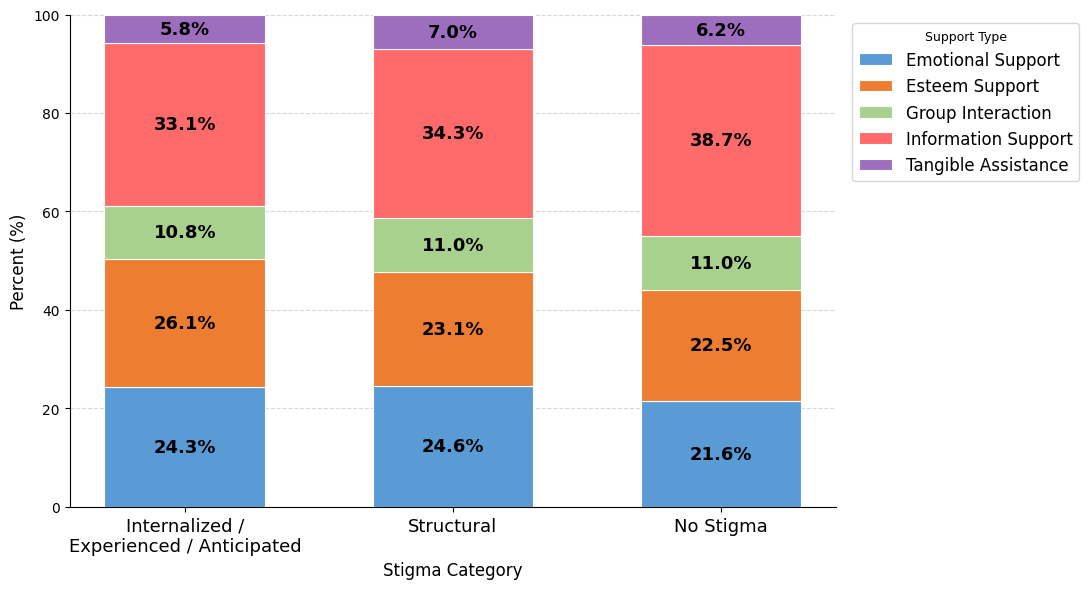

In [110]:
# ══════════════════════════════════════════════════════════════════════
# CELL 8 — DRAW 100% STACKED BAR CHART
#
# One figure, 1 panel.
# x = stigma category
# y = % of support composition within that category
# Each bar totals 100%.
# ══════════════════════════════════════════════════════════════════════

SUPPORT_COLORS = {
    "Emotional Support"  : "#5B9BD5",
    "Esteem Support"     : "#ED7D31",
    "Group Interaction"  : "#A9D18E",
    "Information Support": "#FF6B6B",
    "Tangible Assistance": "#9E6EBE",
}

CAT_TITLES_BAR = {
    CAT_A: "Internalized /\nExperienced / Anticipated",
    CAT_B: "Structural",
    CAT_C: "No Stigma",
}

# Make sure all support types and categories are present
plot_df = bar_pivot.reindex(index=SUPPORT_TYPES, columns=CAT_ORDER, fill_value=0)

# Convert each category column so it sums to 100
plot_df = plot_df.div(plot_df.sum(axis=0), axis=1) * 100

fig, ax = plt.subplots(figsize=(11, 6))

x = np.arange(len(CAT_ORDER))
bottom = np.zeros(len(CAT_ORDER))

for support in SUPPORT_TYPES:
    heights = plot_df.loc[support].values
    bars = ax.bar(
        x,
        heights,
        bottom=bottom,
        color=SUPPORT_COLORS[support],
        edgecolor="white",
        linewidth=0.8,
        width=0.6,
        label=support
    )

    # Add labels inside segments if large enough
    for i, h in enumerate(heights):
        if h >= 5:
            ax.text(
                x[i],
                bottom[i] + h / 2,
                f"{h:.1f}%",
                ha="center",
                va="center",
                fontsize=13,
                fontweight="bold",
                color="black"
            )

    bottom += heights



ax.set_ylabel("Percent (%)", fontsize=12)
ax.set_xlabel("Stigma Category", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels([CAT_TITLES_BAR[c] for c in CAT_ORDER], fontsize=13)
ax.set_ylim(0, 100)

ax.spines[["top", "right"]].set_visible(False)
ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)

ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.01, 1),
    ncol=1,
    fontsize=12,
    title="Support Type",
    title_fontsize=9,
    framealpha=0.8
)

plt.tight_layout()
plt.savefig("stacked_bar_support_pct_100.png", dpi=180, bbox_inches="tight")
print("Saved: stacked_bar_support_pct_100.png")
plt.show()
plt.close()